# Classical Machine Learning: Part 2

## Logistic Regression for Binary Classification ( using Loan Dataset from Kaggle )


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score, classification_report, roc_curve, roc_auc_score, precision_score, f1_score, recall_score)
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('loan_data.csv')

print("Dataset Information:")
print(f'Shape:{data.shape}')
print('\nFirst 5 Records:')
print(data.head())

print('\nSummary Statistics:')
print(data.describe())

print('\nCheck for missing values:')
print(data.isnull().sum())

Dataset Information:
Shape:(45000, 14)

First 5 Records:
   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0        

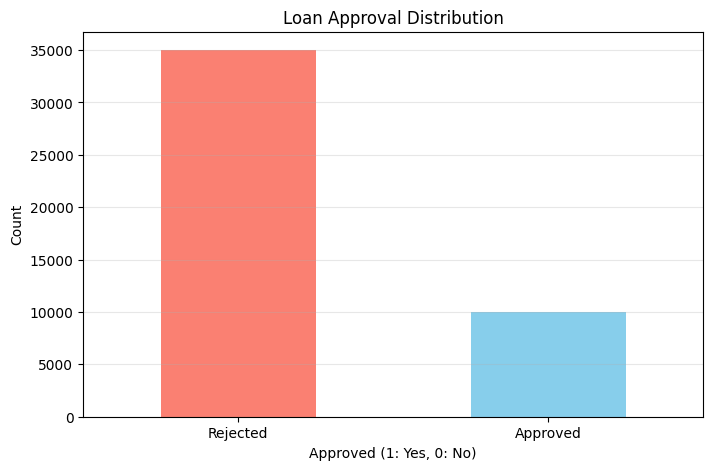

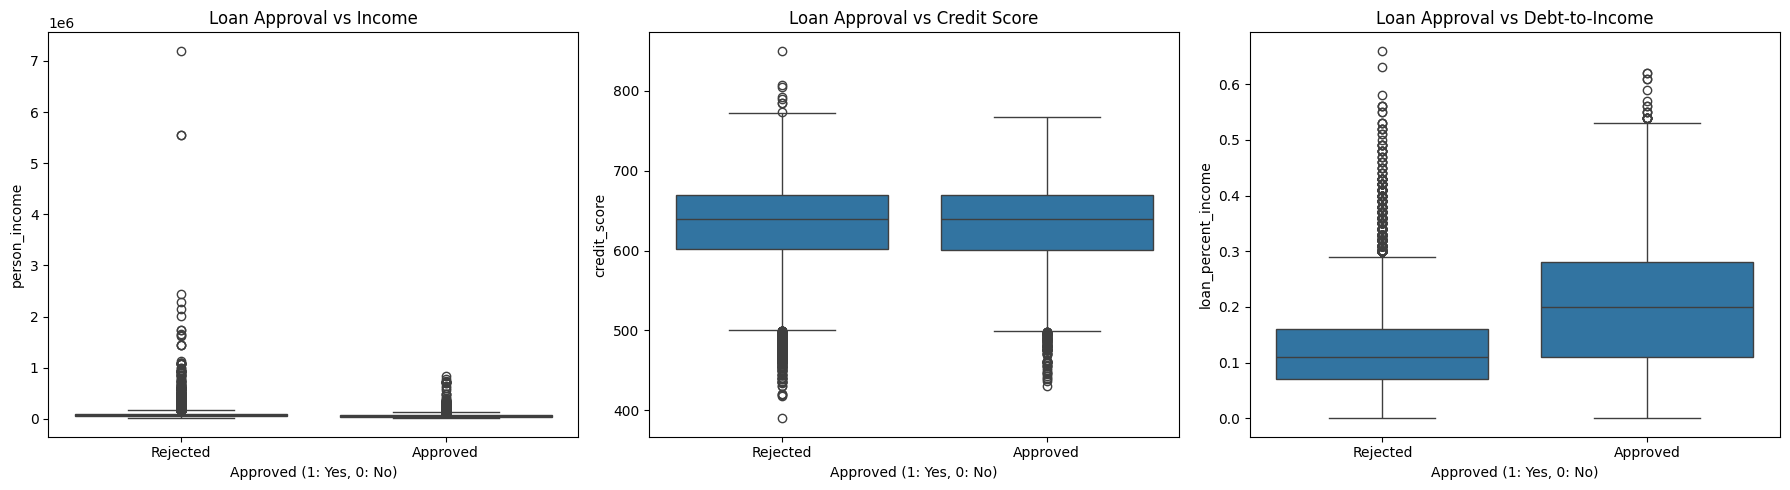

In [3]:
# Visualizing the binary classification of the given dataset
plt.figure(figsize=(8,5))
data['loan_status'].value_counts().plot(kind='bar',color=['salmon','skyblue'])
plt.title('Loan Approval Distribution')
plt.xlabel('Approved (1: Yes, 0: No)')
plt.ylabel('Count')
plt.xticks([0,1],['Rejected','Approved'],rotation=0)
plt.grid(axis='y',alpha=0.3)
plt.show()

fig,axes=plt.subplots(1,3,figsize=(18,5))

# Boxplots of loan_status with three other essential features
sns.boxplot(x='loan_status',y='person_income',data=data,ax=axes[0])
axes[0].set_title('Loan Approval vs Income')
axes[0].set_xlabel('Approved (1: Yes, 0: No)')
axes[0].set_xticklabels(['Rejected','Approved'])

sns.boxplot(x='loan_status',y='credit_score',data=data,ax=axes[1])
axes[1].set_title('Loan Approval vs Credit Score')
axes[1].set_xlabel('Approved (1: Yes, 0: No)')
axes[1].set_xticklabels(['Rejected','Approved'])

sns.boxplot(x='loan_status',y='loan_percent_income',data=data,ax=axes[2])
axes[2].set_title('Loan Approval vs Debt-to-Income')
axes[2].set_xlabel('Approved (1: Yes, 0: No)')
axes[2].set_xticklabels(['Rejected','Approved'])

plt.tight_layout()
plt.show()

From the above distribution, it can be observed that the given dataset is unbalanced, which is not ideal for a logistic regression. Moreover:
- In the first plot, applicants with higher incomes don't necessarily get more approvals
- In the second plot, the credit score distributions are similar across both the classes
- In the third plot, it can be deduced that lower debt-to-income ratio tends to fewer approvals

In [4]:
X=data[['person_income','credit_score','loan_percent_income']]
y=data['loan_status']

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Important for logistic regression
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

model=LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

### Why Logistic Regression is better than Linear Regression ?
- Linear regression outputs unbounded values, not probabilities
- Logistic regression uses the sigmoid function to output values between 0 & 1
- These values represent probabilities, making them ideal for binary classification

Model Coefficients:
person_income: -0.8230
credit_score: -0.0034
loan_percent_income: 0.8158
Intercept: -1.5299


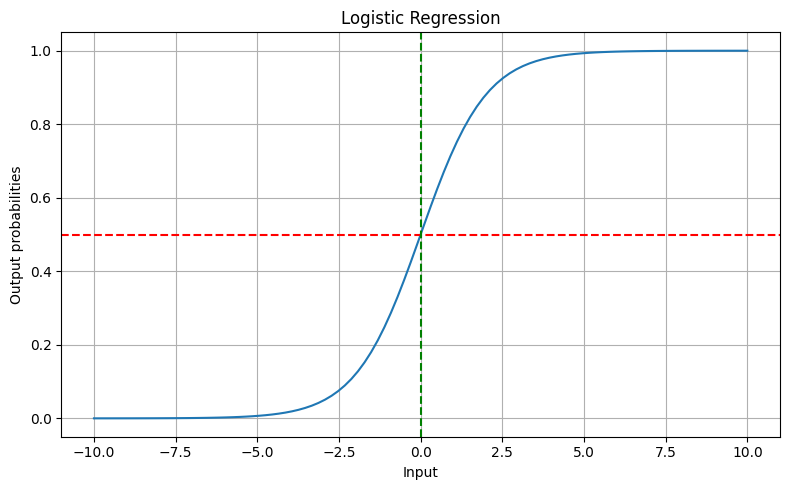

In [5]:
print('Model Coefficients:')
for feature,coef in zip(X.columns,model.coef_[0]):
    print(f'{feature}: {coef:.4f}')
print(f"Intercept: {model.intercept_[0]:.4f}")

def sigmoid(x):
    return 1/(1+np.exp(-x))

x=np.linspace(-10,10,100)
y=sigmoid(x)

# Visualizing the sigmoid function
plt.figure(figsize=(8,5))
plt.plot(x,y)
plt.title('Logistic Regression')
plt.xlabel('Input')
plt.ylabel('Output probabilities')
plt.axhline(y=0.5,color='r',linestyle='--')
plt.axvline(x=0,color='g',linestyle='--')
plt.grid(True)
plt.tight_layout()
plt.show()

- Positive coefficient: Feature increases the probability of approval
- Negative coefficient: Feature decreases the probability of approval

Higher income and credit scores negatively impact approval chances, while a higher debt-to-income ratio increases approval chances.

In [6]:
y_pred=model.predict(X_test_scaled)
y_pred_prob=model.predict_proba(X_test_scaled)[:,1]

# Predictions using the testing data
print('\nSample Predictions (First 5):')
example_df=pd.DataFrame({
    'Income':X_test['person_income'].values[:5],
    'Credit Score':X_test['credit_score'].values[:5],
    'Debt-to-Income':X_test['loan_percent_income'].values[:5],
    'True Label':y_test.values[:5],
    'Predicted':y_pred[:5],
    'Probability':np.round(y_pred_prob[:5],3)
})
print(example_df)

new_applicant=np.array([[75000,700,0.20]])
new_applicant_scaled=scaler.transform(new_applicant)
new_prediction=model.predict(new_applicant_scaled)[0]
new_probability=model.predict_proba(new_applicant_scaled)[0,1]

print("\nNew Loan Application:")
print(f'Income: 75000.0, Credit Score: 700, Debt-to-Income: 0.20')
print(f'Prediction: {"Approved" if new_prediction==1 else "Rejected"}')
print(f'Approval Probability: {new_probability:.2f} or {new_probability*100:.1f}%')


Sample Predictions (First 5):
    Income  Credit Score  Debt-to-Income  True Label  Predicted  Probability
0  96865.0           601            0.08           0          0        0.087
1  56838.0           647            0.16           0          0        0.266
2  37298.0           711            0.13           1          0        0.267
3  39944.0           597            0.13           0          0        0.261
4  67974.0           586            0.15           1          0        0.219

New Loan Application:
Income: 75000.0, Credit Score: 700, Debt-to-Income: 0.20
Prediction: Rejected
Approval Probability: 0.29 or 28.5%


In [7]:
accuracy=accuracy_score(y_test,y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

Model Accuracy: 0.8202

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      6990
           1       0.71      0.33      0.45      2010

    accuracy                           0.82      9000
   macro avg       0.77      0.65      0.67      9000
weighted avg       0.81      0.82      0.79      9000



<Figure size 600x500 with 0 Axes>

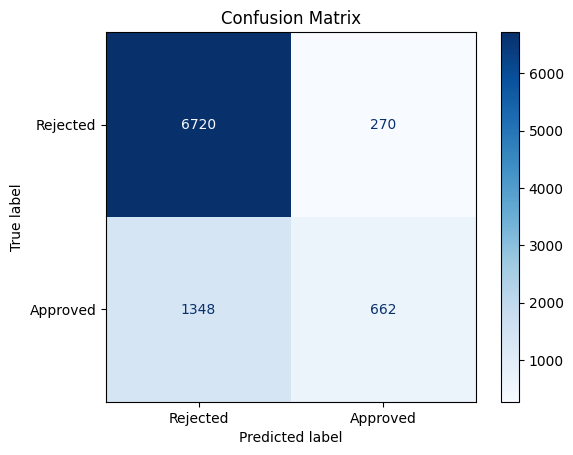


Confusion Matrix components:
True Positives (TP): 662 - Correctly predicted as approved
True Negatives (TN): 6720 - Correctly predicted as rejected
False Positives (FP): 270 - Wrongly predicted as approved (Type-I error)
False Negatives (FN): 1348 - Wrongly predicted as rejected (Type-II error)


In [8]:
cm=confusion_matrix(y_test,y_pred)
cmd=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected','Approved'])

# Confusion Matrix
plt.figure(figsize=(6,5))
cmd.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

tn, fp, fn, tp=cm.ravel()
print("\nConfusion Matrix components:")
print(f'True Positives (TP): {tp} - Correctly predicted as approved')
print(f'True Negatives (TN): {tn} - Correctly predicted as rejected')
print(f'False Positives (FP): {fp} - Wrongly predicted as approved (Type-I error)')
print(f'False Negatives (FN): {fn} - Wrongly predicted as rejected (Type-II error)')

In the context of the above dataset, FPs might lead to financial losses while FNs lead to missed business opportunities.


Detailed metrics:
Precision: 0.7103 - Proportion of correct approvals among predicted approvals
Recall: 0.3294 - Proportion of actual approvals correctly identified
F1 Score: 0.4500 - Harmonic mean of precision & recall


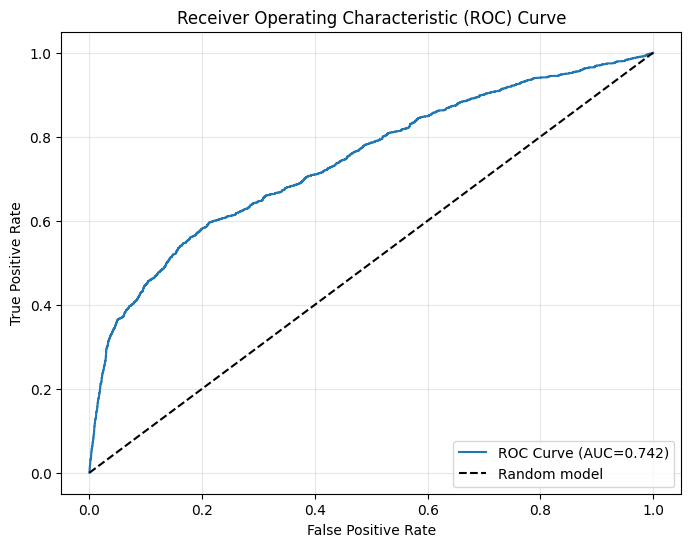

In [9]:
# Key Metrics of the Logistic Regression Model
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print('\nDetailed metrics:')
print(f'Precision: {precision:.4f} - Proportion of correct approvals among predicted approvals')
print(f'Recall: {recall:.4f} - Proportion of actual approvals correctly identified')
print(f'F1 Score: {f1:.4f} - Harmonic mean of precision & recall')

fpr, tpr, thresholds=roc_curve(y_test, y_pred_prob)
auc=roc_auc_score(y_test,y_pred_prob)

# Visualizing the ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--',label='Random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True,alpha=0.3)
plt.show()

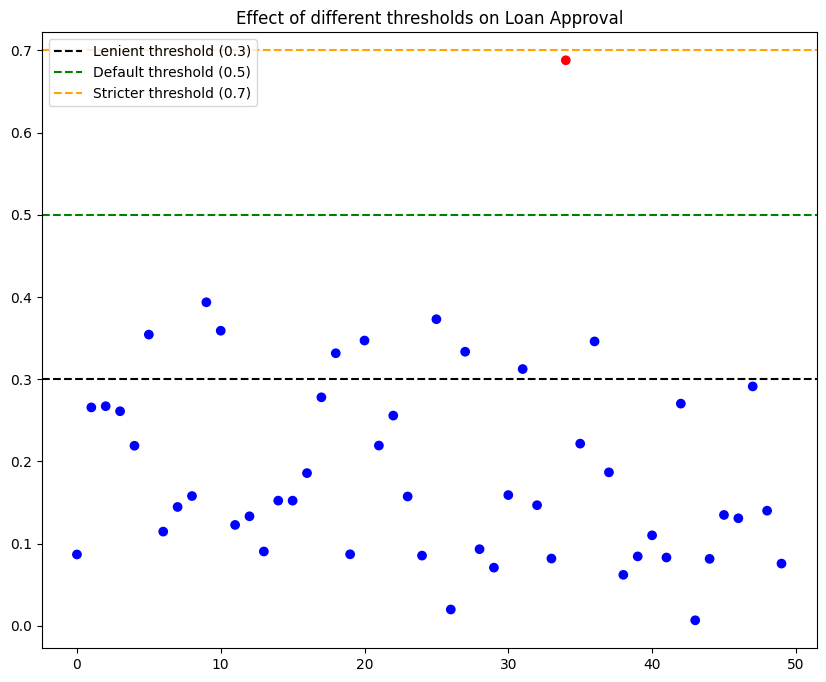

In [10]:
plt.figure(figsize=(10,8))

prob_subset=y_pred_prob[:50]
indices=range(len(prob_subset))

# Visualizing effects of different threshold values on loan approval
plt.scatter(indices,prob_subset, c=['red' if p>0.5 else 'blue' for p in prob_subset])
plt.axhline(y=0.3,color='k',linestyle='--',label='Lenient threshold (0.3)')
plt.axhline(y=0.5,color='g',linestyle='--',label='Default threshold (0.5)')
plt.axhline(y=0.7,color='orange',linestyle='--',label='Stricter threshold (0.7)')
plt.title('Effect of different thresholds on Loan Approval')
plt.legend(loc='upper left')
plt.show()

### Business Implications
- A stricter threshold reduces false positives but increases false negatives -> Fewer bad loans but might reject good customers
- A more lenient threshold increases false positives but reduces false negatives -> Approves more loans to good customers, but also to risky applicants